<script type="text/x-mathjax-config">
  MathJax.Hub.Config({
    tex2jax: {
      inlineMath: [['$','$'], ['\\(','\\)']],
      displayMath: [['$$','$$'], ['\\[','\\]']]
    },
    TeX: {
      extensions: ["color.js"]
    },
    "HTML-CSS": {
      availableFonts: ["TeX"],
      linebreaks: { automatic: true }
    }
  });
</script>

<script src="https://cdn.jsdelivr.net/npm/mathjax@2/MathJax.js?config=TeX-AMS-MML_HTMLorMML" type="text/javascript"></script>

<!-- libreria per paginazione -->
<script src="https://unpkg.com/pagedjs/dist/paged.polyfill.js"></script>

<style>
@media all {
  body {
    font-weight: 700;
  }
  /* Rende le formule MathJax più spesse */
  .MathJax, .MathJax_Display {
    font-weight: bold;
  }
  .bold-text {
    font-weight: bold;
  }
  .heavy-text {
    font-weight: 700;
  }
}


/* Solo per la stampa/PDF */
@media print {
  @page {
    size: auto;
    margin: 7mm 0mm 10mm 0mm; /* margini come prima, solo un po' più basso */
  }

  /* Solo footer con numeri, nessun header */
  @page {
    @top-center {
      content: none;
    }
    @bottom-center {
      content: counter(page) " / " counter(pages);
      font-size: 9pt;
      font-weight: normal;
      color: #333;
    }
  }
}
</style>


<span style="font-size: 14px;">

# 3 Regression

## 3.1 Interpretation of Coefficients and Statistical Significance in LM/GLM

- z (colonna "z"): <br>
    È la statistica test per la regressione logistica Calcolata come: coefficiente / errore standard Misura quanto il coefficiente è significativo rispetto al suo errore
- P>|z| (p-value): <br>
    È la probabilità che il coefficiente sia zero (ipotesi nulla) <br>
    Se P>|z| < 0.05 → il coefficiente è statisticamente significativo <br>
    Se P>|z| > 0.05 → il coefficiente potrebbe essere dovuto al caso <br>
    Lag1 ha P>|z| = 0.145, quindi non è significativo <br>
- [0.025   0.975] (intervallo di confidenza al 95%): <br>
    Sono i limiti inferiore e superiore dell'intervallo di confidenza <br>
    Il vero coefficiente ha il 95% di probabilità di trovarsi in questo intervallo <br>
    Più stretto è l'intervallo, più precisamente è stimato il coefficiente

The smallest p-value here is associated with Lag1. The negative coefficient for this predictor suggests that if the market had a positive return yesterday, then it is less likely to go up today. However, at a value of 0.145, the p-value is still relatively large, and so there is no clear evidence of a real association between Lag1 and Direction.

Today and Direction are linked by a deterministic relationship (if Today > 0, then Direction = Up). This implies that Today cannot be used as a predictor, since it already contains the target information (data leakage). In the correlation matrix, the value is not equal to 1 because the two variables are not both continuous (one is numerical, the other is categorical), so standard linear correlation is not directly applicable

<span style="font-size: 14px;">

## 3.2 Multiple linear Regression

$d =$ number of features

$ \displaystyle \vec{x} = [ 1 \ x_1 \ x_2 \ ... \ x_d]^T  \quad \in \mathbb{R}^{d+1} = $ feature vector [(d+1) x 1]

$ \displaystyle \vec{w} = [w_0 \ w_1 \ ... \ w_d]^ T  \quad \in \mathbb{R}^{d+1} = $ weight vector; $\quad w_0 = $ bias / intercept

$ \displaystyle y = \vec{w}^T \vec{x} \quad \in \mathbb{R} \quad = $ predicted output

$ \displaystyle t \hspace{4em} \in \mathbb{R} \quad = $ real output = target

$ \epsilon = t - y = t - \vec{w}^T \vec{x}  \quad \in \mathbb{R} \quad \epsilon= $ error

$N =$ number of samples

If $ \vec{w}$ is the weight vector that minimizes the Cost Function <br> 
$\hspace{3em}$ the $ \mathcal{J} =  \sum_{i=1}^N \epsilon^2 \hspace{2.3em} \Rightarrow \quad \vec{w}^{LS} \hspace{2em}$ LEAST SQUARES <br>
$\hspace{3em}$ the $ \mathcal{J} = \frac{1}{N} \sum_{i=1}^N \epsilon^2 \hspace{1.2em} \Rightarrow \quad \vec{w}^{MSE} \hspace{1.3em}$ MEAN SQUARED ERROR <br>
$\hspace{3em}$ the $ \mathcal{J} = \sqrt{ \frac{1}{N} \sum_{i=1}^N \epsilon^2} \hspace{.5em} \Rightarrow \quad \vec{w}^{RMSE} \hspace{.5em}$ ROOT MEAN SQUARED ERROR <br>
$\hspace{3em}$ the $ \mathcal{J} = \frac{1}{N} \sum_{i=1}^N |\epsilon| \quad \Rightarrow \quad \vec{w}^{MAE} \quad$ MEAN ABSOLUTE ERROR

$ \displaystyle X = [ \vec{x_1}^T \ \vec{x_2}^T \ ... \ \vec{x_N}^T]^T \quad \in \mathbb{R}^{N \times (d+1)} = \quad $ feature matrix [N x (d+1)]

$ \displaystyle \vec{y} = [y_1 \ y_2 \ ... \ y_N]^T = X \vec{w} \quad \in \mathbb{R}^{N} = \quad $ predicted output vector [N x 1]

$ \displaystyle \vec{t} = [t_1 \ t_2 \ ... \ t_N]^T  = \vec{y} + \vec{\epsilon}\quad \in \mathbb{R}^{N} = \quad $ real output vector

$ \displaystyle \mathcal{D} = [X y] = \{(\vec{x}_i, t_i)\}_{i=1}^N \quad = $ DataSet = DataTrain $ \cup $ DataTest


<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

# 4 Classification

$d =$ number of features

$ \displaystyle \vec{x} = [ 1 \ x_1 \ x_2 \ ... \ x_d]^T  \quad \in \mathbb{R}^{d+1} = $ feature vector

$ \displaystyle \vec{w} = [w_0 \ w_1 \ ... \ w_d]^ T  \quad \in \mathbb{R}^{d+1} = $ weight vector; $\quad w_0 = $ bias / intercept

$ \displaystyle y = f(\vec{w}^T \vec{x}) \quad \in Classes \subseteq \mathbb{N} \quad = $ predicted output vector

$ \displaystyle t \hspace{6em}  \in Classes \subseteq \mathbb{N} \quad = $ real output = target

$N =$ number of samples

$ \displaystyle p(t^i \mid \vec{x}^i ; \vec{w}) \quad i \in{1..N} \quad = $ distribution of $t^i$ given $\vec{x}^i$ and parametrized by $\vec{w}$

$ \displaystyle L(\vec{w}) = p(\vec{t} \mid X; \vec{w}) \quad =$ Likelihood

$ \displaystyle l(\vec{w}) = - \log  L(\vec{w}) \quad = $ negative log likelihood (NLL)

$ \displaystyle \vec{w}$ is the weight vector that maximixes the L, i.e., miniminizes the NLL, i.e., minimizes <br>
$\hspace{3em}$ the $\mathcal{J} = -\frac{1}{N} \sum_{i=1}^N \log p(t^i \mid \vec{x}^i ; \vec{w})  \hspace{2em} \Rightarrow \quad \vec{w}^{LS} \hspace{2em}$ LEAST SQUARES <br>

$ \displaystyle X = [ \vec{x_1} \ \vec{x_2} \ ... \ \vec{x_N}]^T = \quad $ feature matrix

$ \displaystyle \vec{y} = [y_1 \ y_2 \ ... \ y_N]^T = \quad $ predicted output vector

$ \displaystyle \vec{t} = [t_1 \ t_2 \ ... \ t_N]^T = \quad $ real output vector

$ \displaystyle \mathcal{D} = [X y] = \{(\vec{x}_i, t_i)\}_{i=1}^N \quad = $ DataSet = DataTrain $ \cup $ DataTest

<span style="font-size: 14px;">

## 4.1 The Stock Market Dataset

This data set consists of percentage returns for the S&P 500 stock index over 1.250 days, from the beginning of 2001 until the end of 2005.
For each date, we have recorded the 
- Year: the dataset is ordered, so instead of having the full date, only the year is provided.
- percentage returns for each of the five previous trading days, 
    - Lag1 is the percentage return of the day before
    - Lag2 is the percentage return of 2 days before
    - ...
    - Lag5 is the percentage return of 5 days before
- Volume (the number of shares traded on the previous day, in billions), 
- Today (the percentage return on the date in question) 
- Direction (whether the market was Up or Down on this date).

In [1]:
# Install ISLP package if not already installed (for Colab environment)
try:
    import ISLP
except ImportError:
    import sys
    !{sys.executable} -m pip install ISLP -q

In [2]:
# Import libraries & Datasets
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_curve, auc

threshold = 0.5 # limit for classifying as 'Up' (1) vs 'Down' (0)

# Load the Smarket data and display its information

Smarket = load_data('Smarket')
Smarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1250 non-null   int64   
 1   Lag1       1250 non-null   float64 
 2   Lag2       1250 non-null   float64 
 3   Lag3       1250 non-null   float64 
 4   Lag4       1250 non-null   float64 
 5   Lag5       1250 non-null   float64 
 6   Volume     1250 non-null   float64 
 7   Today      1250 non-null   float64 
 8   Direction  1250 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 79.6 KB


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
Year,1.000,0.030,0.031,0.033,0.036,0.030,0.539,0.030,0.075
Lag1,0.030,1.000,-0.026,-0.011,-0.003,-0.006,0.041,-0.026,-0.040
Lag2,0.031,-0.026,1.000,-0.026,-0.011,-0.004,-0.043,-0.010,-0.024
Lag3,0.033,-0.011,-0.026,1.000,-0.024,-0.019,-0.042,-0.002,0.006
Lag4,0.036,-0.003,-0.011,-0.024,1.000,-0.027,-0.048,-0.007,0.004
Lag5,0.030,-0.006,-0.004,-0.019,-0.027,1.000,-0.022,-0.035,0.005
Volume,0.539,0.041,-0.043,-0.042,-0.048,-0.022,1.000,0.015,0.023
Today,0.030,-0.026,-0.010,-0.002,-0.007,-0.035,0.015,1.000,0.731
Direction,0.075,-0.040,-0.024,0.006,0.004,0.005,0.023,0.731,1.000


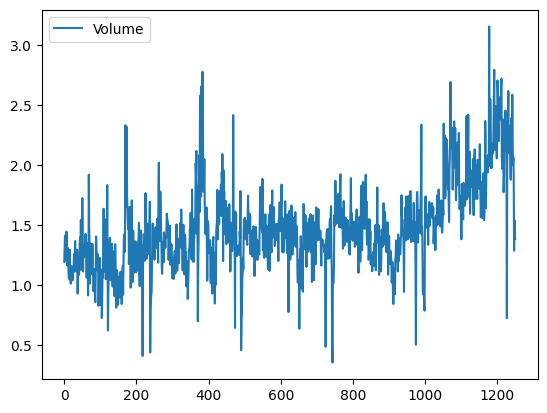

In [3]:
# Correlation Matrix
# The Direction variable because it is qualitative, we need to convert it to numeric for correlation analysis

Smarket_numeric = Smarket.copy()
Smarket_numeric['Direction'] = Smarket_numeric['Direction'].map({'Up': 1, 'Down': 0})
Smarket.plot(y='Volume')
Smarket_numeric.corr().style.background_gradient(cmap='coolwarm').format('{:.3f}')

<span style="font-size: 14px;">

## 4.2 Classification Model Evaluation

The bias–variance decomposition is formally derived for regression with squared loss, <br>
but the bias–variance tradeoff applies to both regression and classification models.

- Bias is the error introduced by approximating a real-world problem with a simplified model.
- For e.g., if the real data follows a non-linear relationship between the features and target variable, and we use a linear model (e.g., Linear Regression) to fit the data – the model is biased.
- In a classification task, if the real data is not linearly separable, and we use a linear model (e.g., Logistic Regression) to fit the data – the model is biased.
- High-bias classifiers make strong assumptions about the data.
- However, making certain assumptions about the data allows us to learn useful models that enable scalability, speed and generalization

In classification, performance is typically evaluated using metrics such as the confusion matrix, accuracy, <br>
precision, recall, or cross-entropy loss, rather than an explicit bias–variance decomposition.

In [4]:
model_results = [] # List to store model results for summary

# Function to add model results to the summary list
def add_model_result(name, accuracy):
    """
    name: string (2–4 chars, es. 'NB', 'KNN', 'SVM')
    accuracy: float
    """
    model_results.append({
        "Model": name,
        "Accuracy": accuracy
    })

In [5]:
# evaluate_model utility function
def evaluate_model(my_prob, my_pred, L_test):
    """
    Utility function to evaluate the model performance
    my_prob: predicted probabilities for the positive class (Up)
    my_pred: predicted class labels (0 or 1)
    L_test: true class labels for the test set
    """
    from sklearn.metrics import confusion_matrix

    # Print confusion matrix with percentages
    confMat = confusion_matrix(my_pred, L_test)
    total = confMat.sum()
    confMat_pct = (confMat / total * 100).round(2)
    print("\nConfusion Matrix:(true value in the columns, predicted in the rows)\n          Down              Up")
    print(f"Down   {confMat[0][0]:.0f}({confMat_pct[0][0]:.2f}%)     {confMat[0][1]:.0f}({confMat_pct[0][1]:.2f}%)")
    print(f"Up     {confMat[1][0]:.0f}({confMat_pct[1][0]:.2f}%)     {confMat[1][1]:.0f}({confMat_pct[1][1]:.2f}%)")

    # Print accuracy and error rate
    accuracy = np.mean(my_pred == L_test)
    error = 1 - accuracy
    print(f"\nAccuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Error Rate: {error:.4f} ({error*100:.2f}%)")

    # Check that predicted labels match the probabilities
    # If P(Up) >= threshold → predict Up (1), else Down (0)
    check = np.all(np.where(my_prob[:,1] >= threshold, True,False) == my_pred) 
    print(f"\nCheck predictions match probabilities: {check}")

    # Count how many observations have a very high probability of being 'Down'
    # Here, P(Down) > 0.9 is considered high confidence
    count = np.sum(my_prob[:,0] > 0.9)
    print(f"Observations with P(Down) > 0.9: {count}")

    TPR = confMat[1][1] / (confMat[1][0] + confMat[1][1]) if (confMat[1][0] + confMat[1][1]) > 0 else 0
    FPR = confMat[0][1] / (confMat[0][0] + confMat[0][1]) if (confMat[0][0] + confMat[0][1]) > 0 else 0
    
    # --- ROC Curve ---
    y_score = my_prob[:, 1]  # probabilità della classe positiva
    fpr, tpr, roc_thresh = roc_curve(L_test, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
    
    # evidenzio il punto della soglia usata
    idx = (np.abs(roc_thresh - threshold)).argmin()
    plt.scatter(fpr[idx], tpr[idx], color='red', label=f'Threshold={threshold}')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    return confMat, accuracy, error, TPR, FPR

In [6]:
# model_summary utility function
def model_summary(model):

    # 1. STATSMODELS (GLM, OLS)
    if hasattr(model, "summary"):
        try:
            pd.set_option('display.max_columns', None)
            pd.set_option('display.width', 80)
            print(model.summary())
            return
        except:
            pass

    # 2. SVM (SVC)
    from sklearn.svm import SVC
    if isinstance(model, SVC):
        print("SVM Summary\n")
        print(f"Kernel: {model.kernel}")
        print(f"C: {model.C}")
        print(f"Intercept: {model.intercept_[0]:.4f}")
        print(f"Support vectors per class: {model.n_support_}")
        print(f"Total support vectors: {model.n_support_.sum()}")

        if model.kernel == 'linear' and hasattr(model, "coef_"):
            print("\nCoefficients:")
            for name, coef in zip(model.feature_names_in_, model.coef_[0]):
                print(f"{name}: {coef:.4f}")

        return

    # 3. KNN
    from sklearn.neighbors import KNeighborsClassifier
    if isinstance(model, KNeighborsClassifier):
        print("KNN Summary\n")
        print(f"k: {model.n_neighbors}")
        print(f"Metric: {model.metric}")
        return

    # 4. Decision Tree
    from sklearn.tree import DecisionTreeClassifier
    if isinstance(model, DecisionTreeClassifier):
        print("Decision Tree Summary\n")
        print(f"Depth: {model.get_depth()}")
        print(f"Leaves: {model.get_n_leaves()}")
        return

    # 5. LDA / QDA
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

    if isinstance(model, LinearDiscriminantAnalysis):
        print("LDA Summary\n")
        print(f"Priors: {model.priors_}")
        print(f"Means:\n{model.means_}")
        return

    if isinstance(model, QuadraticDiscriminantAnalysis):
        print("QDA Summary\n")
        print(f"Priors: {model.priors_}")
        return
    
    # 6. Gaussian Naive Bayes
    from sklearn.naive_bayes import GaussianNB

    if isinstance(model, GaussianNB):
        print("Gaussian Naive Bayes Summary\n")

        print(f"Class priors: {model.class_prior_}")

        print("\nFeature means per class:")
        for i, cls in enumerate(model.classes_):
            print(f"Class {cls}:")
            for name, mean in zip(model.feature_names_in_, model.theta_[i]):
                print(f"  {name}: {mean:.4f}")

        print("\nFeature variances per class:")
        for i, cls in enumerate(model.classes_):
            print(f"Class {cls}:")
            for name, var in zip(model.feature_names_in_, model.var_[i]):
                print(f"  {name}: {var:.4f}")

        return

    # Others Models
    print("No specific summary available.")

<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

## 4.3 Classification Models

- **Classification vs Clustering**

  Classification means assigning data points to **predefined classes**.  
  The learning phase is always **supervised**, since the model is trained using labeled data $(x_i, y_i)$. <br>
  Clustering, instead, means grouping data points based on **similarity or analogies** between them.  
  The grouping structure is therefore **data-dependent and dynamic**, and clustering is typically **unsupervised**, since no predefined labels or classes are available.
  
- **Discriminative models**  
  Learn the conditional distribution $P(y \mid x)$ or directly the decision boundary, i.e., which features are most useful to discriminate between the classes.

- **Generative models**  
  Learn the joint distribution $P(x, y) = P(x \mid y) P(y)$, i.e., how to generate some input data, i.e., the distribution of the inputs x.

- **Parametric models**  
  Fixed number of parameters (independent of dataset size $N$).

- **Non-parametric models**  
  Model complexity grows with the data.

|                      | Discriminative        | Generative        |
|----------------------|----------------------|-------------------|
| **Parametric**       | LR, SVM, NN          | NB, LDA, QDA, GMM  |
| **Non-parametric**   | DT, KNN              | —                 |

- **LR — Logistic Regression**  
  Estimates $P(y \mid x)$ using a logistic (sigmoid) function. $\quad \vec x \in \mathbb{R}^n$ 

- **SVM — Support Vector Machine**  
  Finds a hyperplane that maximizes the margin between classes. $\quad \vec x \in \mathbb{R}^n$ 

- **NN — Neural Network**  
  Composes multiple nonlinear transformations to model complex decision boundaries. $\quad \vec x \in \mathbb{R}^n$

- **DT — Decision Tree**  
  Recursively partitions the feature space using decision rules.$\quad \vec x \in \mathbb{N}^n$ or $\vec x \in \mathbb{R}^n$

- **KNN — K-Nearest Neighbors**  
  Classifies a sample based on the labels of its nearest neighbors (instance-based learning).$\quad \vec x \in \mathbb{R}^n$

- **NB — Naive Bayes**  
  Uses Bayes theorem with conditional independence assumption: $P(x \mid y) = \prod_i P(x_i \mid y). \quad \vec x \in \mathbb{N}^n$  or $\vec x \in \mathbb{R}^n$

- **GDA — Gaussian Discriminant Analysis** <br>
  Assumes Gaussian distributions $\quad \vec x \in \mathbb{R}^n$

  - **LDA — Linear Discriminant Analysis**  
  GDA with shared covariance matrix → linear boundaries.
  - **QDA — Quadratic Discriminant Analysis**  
  GDA with class-specific covariance matrices → quadratic boundaries.

- **GMM — Gaussian Mixture Models**  
  Generative model that represents $P(x)$ as a mixture of Gaussian distributions:  
  $P(x) = \sum_{k} \pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k). \quad \vec x \in \mathbb{R}^n$
  
  Gaussian Mixture Models (GMM) can be used both for **clustering** (as an unsupervised probabilistic model) and for **classification** (by applying Bayes rule to compute posterior class probabilities).


<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

### 4.3.1 LR Logistic Regression

$\displaystyle y = f(\vec{x}) = \sigma(\vec{w}^T \vec{x}) \triangleq \frac{1}{1+e^{-\vec{w}^T \vec{x}}}$

If both $y$ and $t \in \{0,1\}$ then for every $i^{th}$ of $N$ samples we have:

$\displaystyle p(t_i=1 \mid \vec{x}_i; \vec{w}) = f(\vec{x}_i) \\
p(t_i=0 \mid \vec{x}_i; \vec{w}) = 1-f(\vec{x}_i) \quad$ merging the two  formulas $ \\
p(t_i \mid \vec{x}_i; \vec{w}) = (f(\vec{x}_i))^{t_i} (1-f(\vec{x}_i))^{1-t_i} \quad  i \in [1,N] $

$ \displaystyle L(\vec{w}) = p(\vec{t} \mid X; \vec{w}) = \Pi_{i=1}^N [f(\vec{x}_i)]^{t_i} [1-f(\vec{x}_i)]^{1-t_i} $

$ \displaystyle l(\vec{w}) = - \log  L(\vec{w}) = - \sum_{i=1}^N  \log [f(\vec{x}_i)]^{t_i} [1-f(\vec{x}_i)]^{1-t_i}  = \\
\hspace{2em} \boxed{
l(\vec{w}) = - \sum_{i=1}^N \left[ t_i \log y_i + (1-t_i)\log(1-y_i) \right]
} \quad$ Binary Cross Entropy loss

solved using Gradient Descent algorithm

---

$  y_{i,k}$ is the predicted probability that the i-th sample belongs to the k-th class.

$ y_i $  is the predicted probability of the true class

$\displaystyle \vec{y}_i = f(\vec{x}_i) = \text{softmax} (W \vec{x}_i + \vec{b}) \quad i \in [1,N]$

$\displaystyle y_{i,k} = \frac{e^{\vec{w}_k^T \vec{x}_i + b_k}}{\sum_{j=1}^K e^{\vec{w}_j^T \vec{x}_i + b_j}}$

$ W \triangleq \left[ \begin{array} {c c c c} w_{1,1} \ w_{1,2} \ ... \ w_{1,d} \\ w_{2,1} \ w_{2,2} \ ... \ w_{2,d} \\
... \\ w_{K,1} \ w_{K,2} \ ... \ w_{K,d} \end{array} \right] \quad \vec{b} \triangleq \left[ \begin{array}{c} b_1 \\ b_2 \\ ... \\ b_K \end{array}\right] \quad t_i $ is one hot i.e. $t_{i,k} = \begin{cases} 1 \text{ if sample } i \text{ belongs to class } k \\ 0 \text{ otherwise } \end{cases}$

$ \displaystyle l(\vec{w}) = - \sum_{i=1}^N \sum_{k=1}^K t_{i,k} \log y_{i,k} = - \sum_{i=1}^N \log y_i \quad $ Cross Entropy loss

solved using Stochastic Gradient Descent algorithm 


                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                  998
Model:                            GLM   Df Residuals:                      995
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -690.70
Date:                Sun, 24 May 2026   Deviance:                       1381.4
Time:                        14:20:24   Pearson chi2:                     998.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.001865
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0322      0.063      0.508      0.6

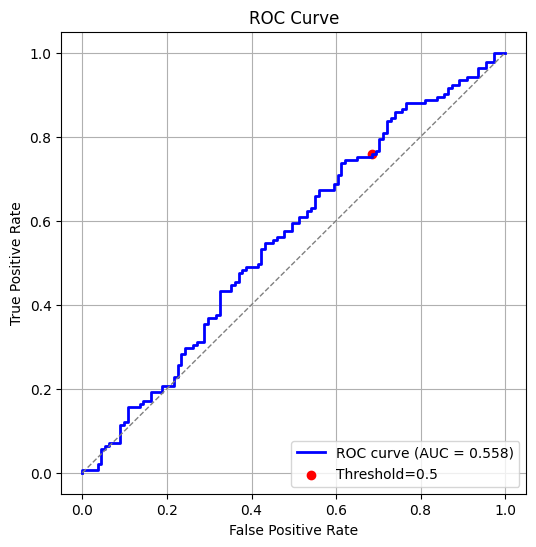

In [7]:
# LR Learning
model = MS(['Lag1', 'Lag2']).fit(Smarket) # using only Lag1 and Lag2 as significant predictors    
X = model.transform(Smarket)
y = Smarket.Direction == 'Up' # Convert 'Up' to True and 'Down' to False for logistic regression

# Train/Test Split 2001-2004 vs 2005
train = (Smarket.Year < 2005)
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
D_train, D_test = Smarket.Direction.loc[train], Smarket.Direction.loc[~train]
L_train, L_test = Smarket.Direction.loc[train].map({'Down': 0, 'Up': 1}), Smarket.Direction.loc[~train].map({'Down': 0, 'Up': 1})

# Model: Train only
glm_train = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm_train.fit()
model_summary(results)

# LR Predictions
LR_prob = results.predict(exog=X_test)
LR_pred = (LR_prob > threshold ).astype(int)
LR_prob_2d = np.column_stack((1 - LR_prob, LR_prob))
_, accuracy, _, _, _ = evaluate_model(LR_prob_2d, LR_pred, L_test)
add_model_result('LR', accuracy)


<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

### 4.3.2 DT Decision Tree

Decision trees make predictions by recursively splitting on different attributes according to a tree structure

Given a training dataset, we need to learn:
- Which attribute to choose for splitting (e.g., width)
    - $p( j \mid R)$ is the class frequency of class $j$ in the region $R$ 
    - Gini Index: GINI $ (R) = 1-\sum_j [p(j \mid R)]^2$ (must be as low as possible)
- What value of that attribute to use for splitting (e.g., width > 6.5 cm)

Classification tree:
- discrete output, i.e., $y \in {1, · · · ,C}$
- leaf value $\hat y_m$ typically set to the most common value (or majority vote) in ${y_{m_1}, · · · , y_{m_k}}$ 

Regression tree:
- continuous output, i.e.m $y \in \mathbb{R}$
- discrete output, i.e., $y \in {1, · · · ,C}$
- leaf value $\hat y_m$ typically set to the mean value in ${y_{m_1}, · · · , y_{m_k}}$ 


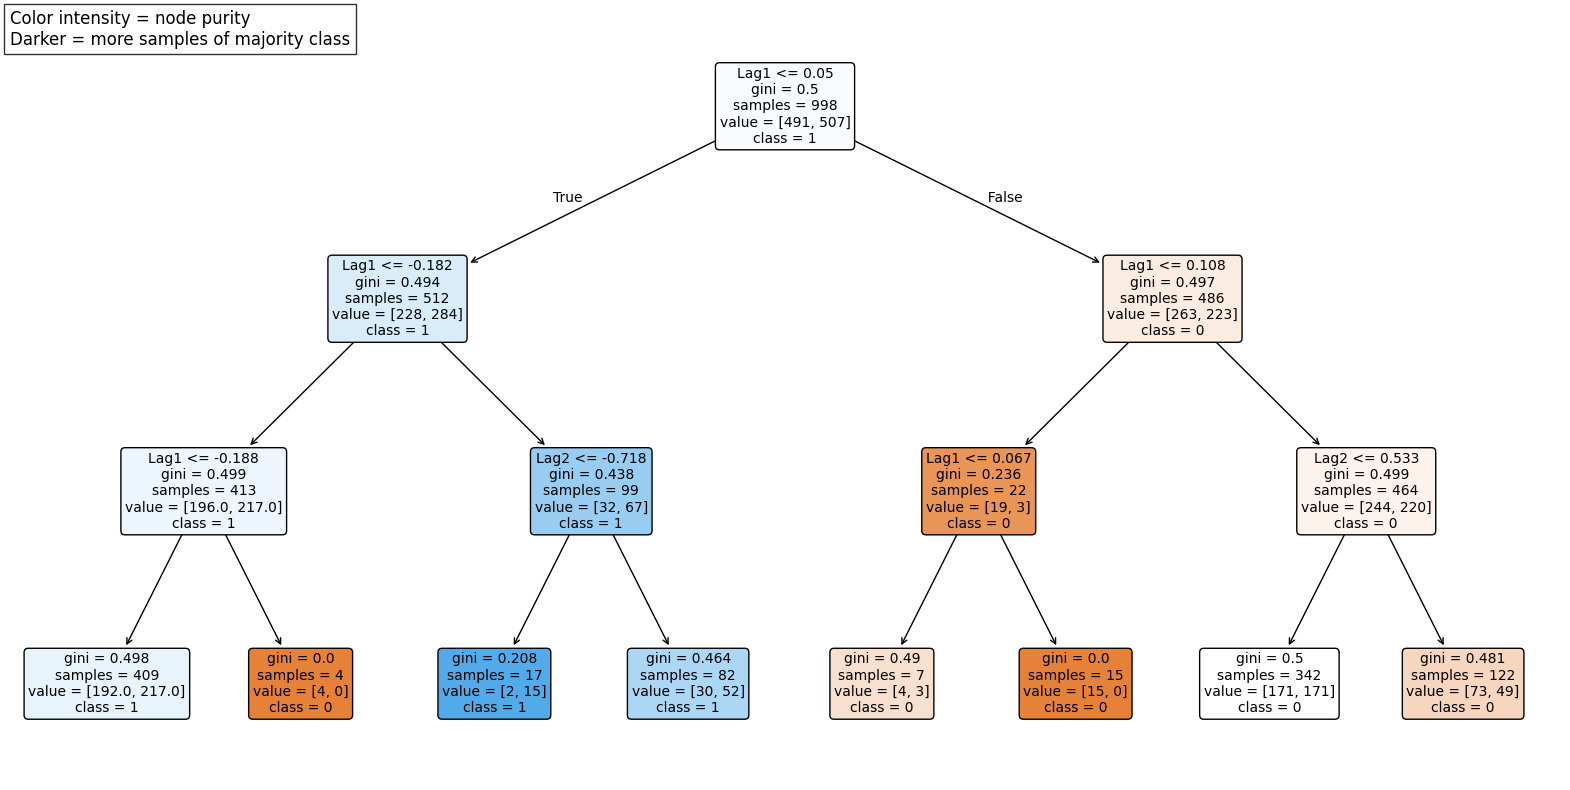

Decision Tree Summary

Depth: 3
Leaves: 8

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   62(24.60%)     66(26.19%)
Up     49(19.44%)     75(29.76%)

Accuracy  : 0.5437 (54.37%)
Error Rate: 0.4563 (45.63%)

Check predictions match probabilities: False
Observations with P(Down) > 0.9: 13


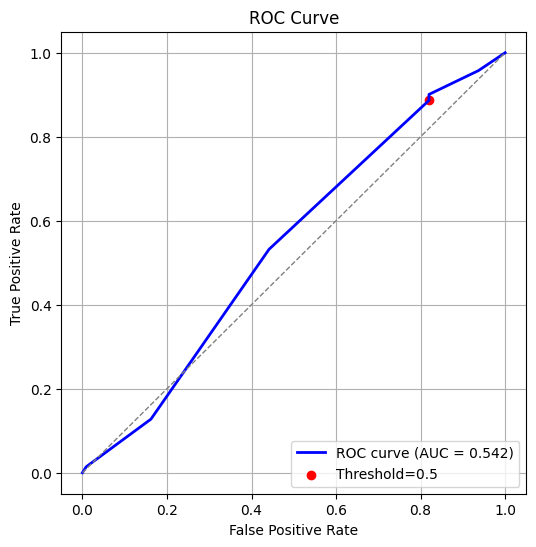

In [8]:

DT = DecisionTreeClassifier(random_state=42, # Using the intergalatic guide to split the dataset
                            max_depth=3)  # other parameters: max_leaf_nodes, min_samples_split, ecc.

DT.fit(X_train, L_train)

feature_names = X_train.columns.tolist()        # prende le colonne di X_train
class_names = [str(c) for c in sorted(L_train.unique())]  # classi ordinate come stringhe
plt.figure(figsize=(20,10))
plot_tree(DT, feature_names=feature_names, class_names=class_names, 
          filled=True, rounded=True, fontsize=10)
plt.text(0, 1, 
         "Color intensity = node purity\nDarker = more samples of majority class",
         fontsize=12, color='black', ha='left', va='top', bbox=dict(facecolor='white', alpha=0.8))
plt.show()
model_summary(DT)

dt_prob = DT.predict_proba(X_test)     # probabilità per ciascuna classe
dt_pred = DT.predict(X_test)           # classi predette
_, accuracy, _, _, _ =evaluate_model(dt_prob, dt_pred, L_test)
add_model_result('DT', accuracy)


<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

### 4.3.3 LDA Linear Determinant Analisys

Bayes' Rule: $\quad p(t=k \mid x) \cdot p(x) = p(x \mid t=k) \cdot p(t=k) \quad $ where:
- $p(x \mid t=k) \hspace{4.6em} $ LIKELIHOOD (probability to have $x$ having the label is $k$)
- $p(t=k) \triangleq \pi_k \hspace{3.7em} $ PRIOR (probability to have the label $k$)
- $p(x) \hspace{7.7em} $ EVIDENCE (probability to have $x$)
- $p(t=k \mid x) \triangleq p_k(x) \hspace{1em} $ POSTERIOR (probability to have the label $k$ having $x$)

Assumption # 1: The class-conditional distribution $p(x \mid t)$ is normal or GAUSSIAN <br>
Assumption # 2: The standard deviation is shared across all the K classes, i.e., $\quad \sigma_k = \sigma \ \forall k \in [1,K]$

$\displaystyle p(x \mid t=k) \triangleq f_k(x) \triangleq \frac{1}{\sqrt {2 \pi \sigma^2}} \exp \left[ - \frac{(x-\mu_k)^2}{2 \sigma^2} \right]$

then using the Bayes' Rule we obtain

$\displaystyle p_k(x)= \frac{ \pi_k \cdot f_k(x)}{p(x)} \quad $ Recall that $\quad p(x) = \sum_{k=1}^K \pi_k \ p(x \mid t=k) $

Finding the largest $p_k(x)$ means find the largest DISCRIMINANT SCORE $\displaystyle \quad \delta_k(x) = \frac{\mu_k}{\sigma^2} \cdot x - \frac{\mu_k^2}{2 \sigma^2} + \log \pi_k$

DECISION BOUNDARY formula (for binary classification): $\quad \displaystyle \frac{\mu_0 - \mu_1}{\sigma^2}  \cdot x - \frac{ \mu_1^2 - \mu_0^2}{2 \sigma^2} + \log \frac{\pi_0}{\pi_1} = 0 \quad$ that is linear $ \quad (mx + q = 0)$

---

Generalizing LDA to the d-dimensional case where the input has $d$ features, i.e., $\vec{x} \in \mathbb{R}^d$

Assumption # 1: The class-conditional distribution is a Multivariate Gaussian Distribution $\quad \sim \mathcal{N}(\vec{\mu}_k, \  \Sigma_k)$ <br>
Assumption # 2: All the classes share the same covariance matrix, i.e., $\quad \Sigma_k = \Sigma \ \forall k \in [1,K]$

$\displaystyle f(\vec{x}) = \frac{1}{(2 \pi)^{d/2} |\Sigma|^{1/2}} \ \exp \left[ - \frac{1}{2} (\vec{x}-\vec{\mu})^T \Sigma^{-1} (\vec{x}-\vec{\mu}) \right]$

$ \Sigma_k = \mathbb{E} \left[ (\vec{x} - \vec{\mu}_k) (\vec{x} - \vec{\mu}_k)^T \mid t=k \right] = \frac{1}{N_k} \ 
\underset{i \ \in \ k-class}{\sum}(\vec{x}_i - \vec{\mu}_k) (\vec{x}_i - \vec{\mu}_k)^T$ <br>
$ \vec{\mu} = [\mu_{k,1} \ \mu_{k,2} \ ... \ \mu_{k,d}]^T$ is a vector in $\mathbb{R}^d$ representing the mean of each features for class $k$<br>
$N_k$ number of samples belonging to class $k$

Finding the largest $p_k(x)$ means find the largest DISCRIMINANT SCORE $\displaystyle \quad \delta_k(x) = \vec{x}^T \Sigma^{-1} \vec{\mu}_k - \frac{1}{2} \vec{\mu}_k^T \Sigma^{-1} \vec{\mu}_k + \log \pi_k$

The DECISION BOUNDARY formulas (for LDA multiclass classification) is still linear, i.e., each class is divided from the other by a linear boundary


LDA Summary

Priors: [0.49198397 0.50801603]
Means:
[[ 1.          0.04279022  0.03389409]
 [ 1.         -0.03954635 -0.03132544]]

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   35(13.89%)     35(13.89%)
Up     76(30.16%)     106(42.06%)

Accuracy  : 0.5595 (55.95%)
Error Rate: 0.4405 (44.05%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 0


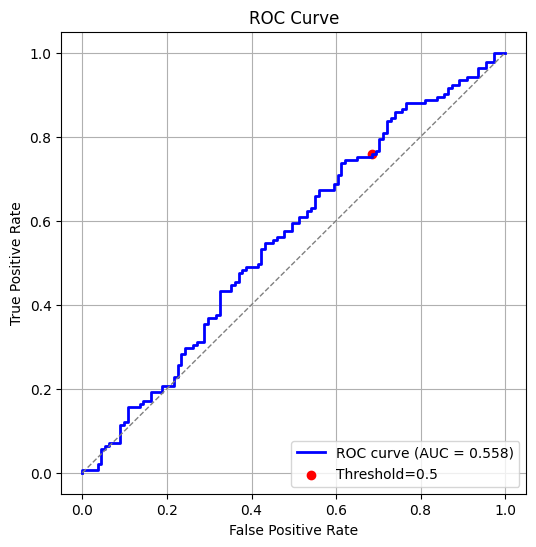

In [9]:
lda = LDA(store_covariance=True)
lda.fit(X_train, L_train)
model_summary(lda)

lda_prob = lda.predict_proba(X_test) # probabilità predette per ciascuna classe
lda_pred = lda.predict(X_test) # predizioni su test set
_, accuracy, _, _, _ = evaluate_model(lda_prob, lda_pred, L_test)
add_model_result('LDA', accuracy)


<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

### 4.3.4 QDA Quadratic Discriminant Analysis — Multiclass Extension

Removing the Assunption # 2 from the LDA multiclass Analysis we have

Assumption # 1: The class-conditional distribution is a Multivariate Gaussian Distribution $\quad \sim \mathcal{N}(\vec{\mu}_k, \  \Sigma_k)$ <br>

$f_k(\vec{x}) = \frac{1}{(2\pi)^{d/2} |\Sigma_k|^{1/2}} 
\exp \left[ - \frac{1}{2} (\vec{x}-\vec{\mu}_k)^T \Sigma_k^{-1} (\vec{x}-\vec{\mu}_k) \right]$

$ \Sigma_k = \mathbb{E} \left[ (\vec{x} - \vec{\mu}_k) (\vec{x} - \vec{\mu}_k)^T \mid t=k \right] = \frac{1}{N_k} \ 
\underset{i \ \in \ k-class}{\sum}(\vec{x}_i - \vec{\mu}_k) (\vec{x}_i - \vec{\mu}_k)^T$ <br>
$ \vec{\mu} = [\mu_{k,1} \ \mu_{k,2} \ ... \ \mu_{k,d}]^T$ is a vector in $\mathbb{R}^d$ representing the mean of each features for class $k$<br>
$N_k$ number of samples belonging to class $k$

Finding the largest $p_k(x)$ means find the largest DISCRIMINANT SCORE $ \displaystyle \delta_k(\vec{x}) = - \frac{1}{2} \log |\Sigma_k| - \frac{1}{2} (\vec{x}-\vec{\mu}_k)^T \Sigma_k^{-1} (\vec{x}-\vec{\mu}_k) + \log \pi_k$

The DECISION BOUNDARY formulas (for QDA multiclass classification) becomes: $\quad \delta_k(\vec{x}) - \delta_j(\vec{x}) = 0 \quad \Rightarrow \quad \text{quadratic in } \vec{x}$

QDA Summary

Priors: [0.49198397 0.50801603]

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   30(11.90%)     20(7.94%)
Up     81(32.14%)     121(48.02%)

Accuracy  : 0.5992 (59.92%)
Error Rate: 0.4008 (40.08%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 0


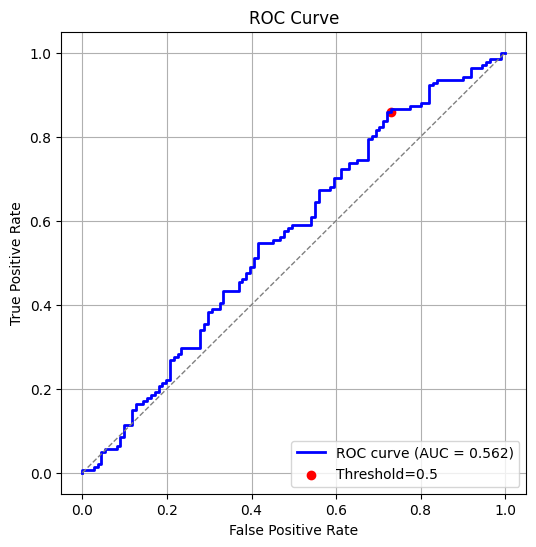

In [10]:
X_train_no_intercept = X_train.drop('intercept', axis=1)
X_test_no_intercept = X_test.drop('intercept', axis=1)
qda = QDA(store_covariance=True)
qda.fit(X_train_no_intercept, L_train)
model_summary(qda)

qda_prob = qda.predict_proba(X_test_no_intercept) # probabilità predette per ciascuna classe
qda_pred = qda.predict(X_test_no_intercept) # predizioni su test set
_, accuracy, _, _, _ = evaluate_model(qda_prob, qda_pred, L_test)
add_model_result('QDA', accuracy)


<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

### 4.3.5 NB Naive Bayes

Classical NB assumes that features are discrete (e.g., words in a text, categories, rating levels).

Assumption # 1: Each feature $x_i$ is modeled as a Gaussian (normal) random variable conditioned on the class $t=k$: <br>

$\hspace{4em} p( x_i \mid t=k )\sim \mathcal{N}(\mu_{k,i}, \ \sigma_{k,i}^2)$

Assumption #2: Conditional independence of features given the class, i.e., knowing the class $t=k$ makes all features independent of each other:

$\hspace{4em} p(\vec{x} \mid t=k) = \prod_{i=1}^d p(x_i \mid t=k)$

This means that the joint probability of observing the feature vector $\vec{x}$ for a given class $k$ can be computed as the product of the individual feature probabilities.

Applying the Bayes' rule we obtain the following formula:

$\hspace{4em} p(t=k \mid \vec{x}) \propto p(t=k) \prod_{i=1}^d p(x_i \mid t=k)$

If the features are discrete, $p(x_i \mid t=k)$ can be estimated as the relative frequency.

For datasets like Stock Market, the features (Lag1, Lag2, Volume, etc.) are continuous numerical, so:

Gaussian Naive Bayes (GNB) is used:

$\hspace{4em} \displaystyle p(x_i \mid t=k) = \frac{1}{\sqrt{2 \pi \sigma_{k,i}^2}} \exp \left[ - \frac{(x_i - \mu_{k,i})^2}{2 \sigma_{k,i}^2} \right]$

Here, it is assumed that each continuous feature, conditioned on the class, follows a Gaussian distribution.Here, each continuous feature conditioned on the class is assumed to follow a Gaussian distribution.

The means $\mu_{k,i}$ and variances $\sigma_{k,i}^2$ are estimated from the data.

NB does not require correlations between features; the conditional independence assumption allows the model to treat each feature separately. Even if the real features are not perfectly Gaussian or independent, 

NB often works surprisingly well as a baseline for classification tasks, including predicting stock market direction.

Gaussian Naive Bayes Summary

Class priors: [0.49198397 0.50801603]

Feature means per class:
Class 0:
  intercept: 1.0000
  Lag1: 0.0428
  Lag2: 0.0339
Class 1:
  intercept: 1.0000
  Lag1: -0.0395
  Lag2: -0.0313

Feature variances per class:
Class 0:
  intercept: 0.0000
  Lag1: 1.5036
  Lag2: 1.5325
Class 1:
  intercept: 0.0000
  Lag1: 1.5140
  Lag2: 1.4873

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   29(11.51%)     20(7.94%)
Up     82(32.54%)     121(48.02%)

Accuracy  : 0.5952 (59.52%)
Error Rate: 0.4048 (40.48%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 0


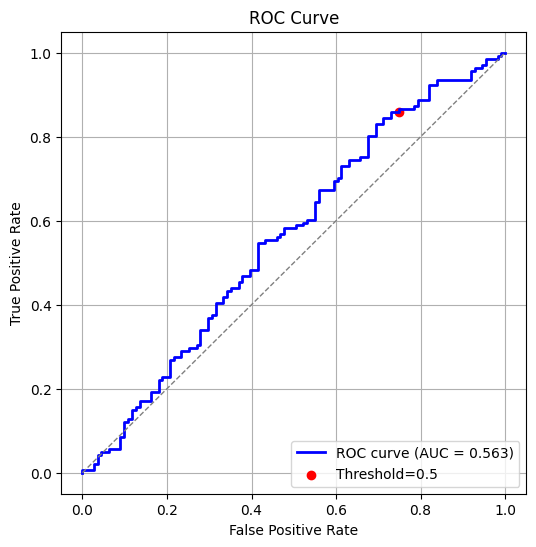

In [11]:
NB = GaussianNB()
NB.fit(X_train, L_train)
model_summary(NB)

nb_prob = NB.predict_proba(X_test)           # probabilità [P(Down), P(Up)]
nb_pred = NB.predict(X_test)                 # classi
_, accuracy, _, _, _ = evaluate_model(nb_prob, nb_pred, L_test)
add_model_result('NB', accuracy)    


<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

### 4.3.6 KNN K_nearest Neighbors

- To classify a given test example x:
    - Find the K nearest neighbours of x
    - Choose as the label the majority label within the K nearest neighbors
- Robust to noisy data by considering K nearest neighbours instead of a single nearest neighbour.
    - Increasing K generally makes the model smoother and less sensitive to noise, reducing variance (but can lead to underfitting if too large).
    - Decreasing K generally makes the model more sensitive to noise, increasing variance and potentially leading to overfitting.
- Question: How do we measure “nearest”?
    - Euclidean distance: is the lenght of the line segment between the 2 points
    - Manhattan distance: is the sum of absolute differences between points across all the dimensions
    - Minkowski distance: is the generalization of the above distances:
        - $D_r(\underline{a}, \underline{b}) = \left( \sum_{k=1}^d |a_k - b_k|^r \right)^{1/r}$
        - $r$ is a parameter ($r=1 \to $ Manhattan; $r=2 \to $ Euclidean)
    - Chebyshev Distance: $D_{\infty}(\underline{a}, \underline{b}) = \max_k (| a_k - b_k)$
    - Hamming distance: tra due stringhe binarie (o vettori) della stessa lunghezza è il numero di posizioni in cui i simboli corrispondenti sono diversi.
    - Cosine Similarity: measures how two vectors are similar to each other
        - $\cos \theta = \frac {\underline{a} \cdot \underline{b}}{|| a || \ ||b||} $
    - Pros:
        - No explicit training.
        - Low bias classifier, i.e., adapts to complex decision boundaries with enough data.
    - Cons:
        - Memory-intensive for large datasets.
        - Slow at prediction time (needs to compute distances to all points): $\mathcal{O}(nd)$.
        - Poor performance in high-dimensional spaces (curse of dimensionality).


KNN Summary

k: 29
Metric: minkowski

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   49(19.44%)     63(25.00%)
Up     62(24.60%)     78(30.95%)

Accuracy  : 0.5040 (50.40%)
Error Rate: 0.4960 (49.60%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 0


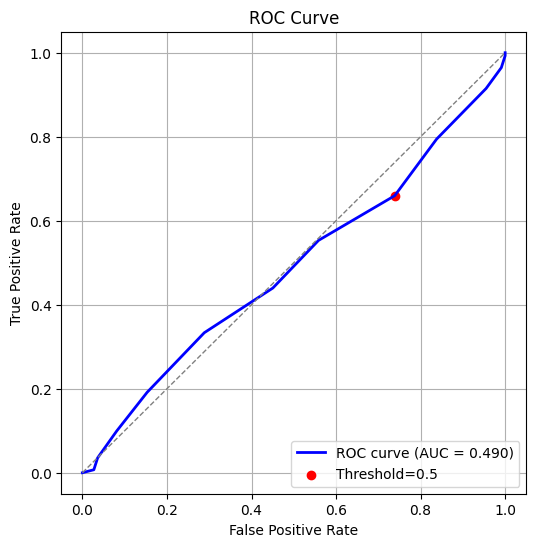

In [12]:

# possible metrics: 'euclidean', 'manhattan', 'chebyshev', 'minkowski', 'hamming'.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': list(range(1, 51))} # try k values from 1 to 50

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='accuracy'
)

grid.fit(X_train, L_train)
knn = grid.best_estimator_  # choose the best model from the grid search

model_summary(knn)

knn_prob = knn.predict_proba(X_test)
knn_pred = knn.predict(X_test)
_, accuracy, _, _, _ = evaluate_model(knn_prob, knn_pred, L_test)
add_model_result(f"KNN_{knn.n_neighbors}", accuracy)

<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

### 4.3.7 SVM Support Vector Machine

- $ \displaystyle \vec{x} = [ 1 \ x_1 \ x_2 \ ... \ x_d]^T  \quad \in \mathbb{R}^{d+1} = $ feature vector; $\quad d =$ number of features
- $ \displaystyle \vec{w} = [w_0 \ w_1 \ ... \ w_d]^ T  \quad \in \mathbb{R}^{d+1} = $ weight vector; $\quad w_0 = $ bias / intercept

- Hyperplane equation: $\hspace{2em} \vec{w} \cdot \vec{x} = \vec{w}^T \vec{x} = \| \vec{w} \| \ \| \vec{x} \| \ \cos \theta = 0$
- Any point $\vec{x}$ such that $\vec{w}^T \vec{x} = 0$ lies on the hyperplane, i.e., $\vec{x}$ is orthogonal to $\vec{w}$
- The separating hyperplane can then be used to classify the data points
$\\[4pt] $ sign $(\vec{w}^T \vec{x}) = \begin{cases} \text{if } \ \vec{w}^T \vec{x} \gt 0 \text{ then} y=+1 \\
 \text{if } \ \vec{w}^T \vec{x} \lt 0 \text{ then} y=-1  \end{cases} \quad$ i.e. $ \quad  y_i \ \vec{w}^T \vec{x}_i \ge 0 \quad \forall i \in [1..N]$
- The distance from a point $P(x_0, y_0)$ and a line $\quad r: a x + b y + c = 0 \quad$ is $\displaystyle \quad d = \frac{| a x_0 + b y_0 + c|}{\sqrt{a^2 + b^2}}$
- More generally: $\quad \displaystyle \|\vec{d} \|_2 = \frac{| \vec{w}^T \vec{x}| }{\| \vec{w}\|_2} \quad$ and thus the margin $\quad \displaystyle \gamma(\vec{w}) = \underset{ \vec{x} \in \mathcal D} {\min}  \frac{| \vec{w}^T \vec{x}| }{\| \vec{w}\|_2}$
- Support vector machine (SVM) is a supervised method for binary classification that allows us to find the best separating hyperplane. We will see three kinds of SVMs:
    - **MMC Maximal Margin Classifier**: the data is strictly linearly separable (as in the case of perceptrons). The best hyperplane is that maximizes the margin. Its proof that to maximize the margin $\gamma(\vec{w})$ means <br>
    $ \hspace{2em} \displaystyle \underset{\vec{w}}{\min} \ \left( \vec{w}^T \vec{w} \right) \quad$ s.t. $\quad y_i \ \vec{w}^T \vec{x}_i \ge 1 \quad \forall i \in [1..N] \quad \text{right classification constraints}$ <br>
    The Support Vectors are the data points that, if changed, move the hyperplane (they are the points on the border of the margins), i.e., $\quad y_j \ \vec{w}^T \vec{x}_j = 1 \quad \forall j \in ${Support Vector index}
    - **SVC Support Vector Classifier**: the data need not be linearly separable, but the decision boundary is still linear. The slack variable $\xi$ that allows the constraints to be violated, i.e. , the $2 \xi$ is the thickness of lenient border. The optimization problem becomes: <br>
    $ \hspace{2em} \displaystyle \underset{\vec{w}}{\min} \ \left( \vec{w}^T \vec{w} + C \sum_{i=1}^N \xi_i \right) \quad$ s.t. $\quad \begin{cases} y_i \ \vec{w}^T \vec{x}_i \ge 1 - \xi_i \quad \forall i \in [1..N] \quad \text{relax constraints} \\ \xi_i \ge 0 \hspace{5.5em} \forall i \in [1..N] \quad \text{non-negative constraints}\end{cases} \\[4pt] C$
    is an hyperparameter: when is large, the penalty for classification error is high and the models tries to get all the points in the right side of the hyperplane. <br>    
    Support Vector are the data points with: $\quad y_i \ \vec{w}^T \vec{x_i} \le 1$ <br>
    Hinge Points are the data points with: $\hspace{2em} y_i \ \vec{w}^T \vec{x_i} = 1$ <br>    
    If $C \ne 0$ we can write the constraints as 
    $\\[4pt] \xi_i = \begin{cases} 0 \hspace{6em} \text{if } y_i \ \vec{w}^T \vec{x}_i \ge 1 
    \\ 1- y_i \ \vec{w}^T \vec{x} \hspace{2em} \text{if } y_i \ \vec{w}^T \vec{x}_i \lt 1 \end{cases} \quad $ i.e. $ \quad \xi_i = \max(0, \ 1-y_i \ \vec{w}^T \vec{x}) \quad $ thus $ \\  \xi_i = \begin{cases} 
    0 \hspace{5em} \text {if } x_i \ \text{is in the right side and out of the tollerance area} \\ 
    \in (0..1] \hspace{2.4em} \text {if } x_i \ \text{ is in the right side but in the tollerance area} \\ \gt 1  \hspace{4em} \text {if } x_i \ \text{is in the wrong side} \end{cases} \\[4pt]$
    By substituting and eliminating the slack variables, the optimization problem becomes: <br>
    $ \hspace{2em} \displaystyle \underset{\vec{w}}{\min} \ \left( \vec{w}^T \vec{w} + C \sum_{i=1}^N \max(0, \ 1- y_i \vec{w}^T\vec{x_i} ) \right)  \quad$ where

        - $\vec{w}^T \vec{w} :\quad l_2$ -regularizer
        - $ \sum_{i=1}^N \max(0, \ 1- y_i \vec{w}^T\vec{x_i} ): \quad $ hinge-loss and is convex and non-differentiable only at the Hinge Points and then is differentiable almost everywhere
    
    This kind of framework in ML is often called **Empirical Risk Minimization (ERM)** where you minimize a loss on the training data points and add a regularization term to favour simpler solutions


    - **SVM Support Vector Machine**: for non-linear decision boundaries. MMC and SVC are special cases of the more general SVM framework <br>
    The Lagrangian function: $\quad \displaystyle \mathcal{L}(\vec{w}, \alpha) \triangleq \frac{1}{2} \|\vec{w}\|^2 - \sum_{i=1}^N \alpha_i \ \left( y_i \ \vec{w}^T \vec{x_i} -1 \right)$ <br>
    The Dual Problem: $\quad \displaystyle \max_{\alpha} \left[ \sum_i \alpha_i - \frac{1}{2} \sum_{i,j} \alpha_i \alpha_j y_i y_j \ (\vec{x}_i^T \vec{x}_j) \right] \quad$ s.t. $\quad \begin{cases} \alpha_i \ge 0 \\ \sum_i \alpha_i y_i = 0 \end{cases}$ <br>
    Since only support vectors have $\alpha \gt 0$ the dual objective effectively depends only on them. <br>
    When the data point are not linearly separable we can transform each data point $\in \mathbb{R}^d$ in a corrisponding point in an higher hyperspace $\in \mathbb{R}^D$ with $D \gg d \quad $ i.e. $ \quad \phi(\vec{x}) \in \mathbb {R}^D \quad $ i.e. $ \quad \phi: \mathbb{R}^d \to \mathbb{R}^D$, <br> choosing the right transformation $\phi$ we can obtain a linear separation between points having different classes. <br>
    The inner product $ ( \vec{x_i}^T \vec{x_j})$ in this new hyperspace becomes the 
    $\\[4pt]$ KERNEL function: $\quad K(\vec{x_i}, \vec{x_j}) \triangleq \phi(\vec{x_i})^T \phi(\vec{x_j})$ <br>
    With particular "smart" transformation function $\phi$, the Kernel function is very easy to calculate, then also the Dual Problem Solution become very fast. The most common transformation function are:
        - LINEAR: when data are linearly separable $\quad K_{LIN}(\vec{x_i}, \vec{x_j}) = \vec{x_i}^T \vec{x_j}$
        - POLYNOMIAL: adds feature interactions up to degree $k$ (k is a new hyperparameter) $\quad K_{POL}(\vec{x_i}, \vec{x_j}) = (\vec{x_i}^T \vec{x_j} + 1)^k$
        - RBF (RADIAL BASIS FORMULA): adds infinitely many features, i.e., $\phi(x)$ is infinite-dimensional and not computed explicitly and use the hyperparameter $\sigma$
        $\\ \displaystyle \phi(x) = e^{- \|x\|^2 / \sigma^2} \left[ 1, \frac{\sqrt{2}}{\sigma} x_1,..., \frac{\sqrt{2}}{\sigma} x_d, \frac{2}{\sqrt{2!} \ \sigma^2} x_1^2, \frac{2}{\sqrt{2!} \ \sigma^2} x_1 x_2 , ..., \frac{2}{\sqrt{2!} \ \sigma^2} x_d^2, ... \right] \\[4pt]
        K_{RBF}(\vec{x_i},\vec{x_j}) = \exp \left( - \frac{(\vec{x_i}-\vec{x_j})^T \ (\vec{x_i}-\vec{x_j}) }{2 \sigma^2} \right)$
        - SIGMOID: The sigmoid kernel can be interpreted as the inner product of transformed features inspired by neural networks, but it does not correspond in general to a valid feature map in a Hilbert space. $k, \theta$ are hyperparameters. <br>
        $ K_{SIG} = \tanh \left (k \ (\vec{x_i}^T \vec{x_j}) + \theta \right) \quad $ where $\displaystyle \quad \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$

        Adding more features increases the probability that the data becomes linearly separable in the transformed space.
    
    - **Multi-class SVM**: there are two popular approaches for multi-class classification:
        - One-versus-one:
            - Construct an SVM for each pair of classes (then $\frac{k (k-1)}{2}$ models)
            - To classify a new observation
                - apply all the models to the new data point
                - pick the most frequent class among all the models
            - Computationally expensive for a large value of k
        - One-versus-all
            - Construct an SVM for each class by treating the other classes as a unique negative class (then k models)
            - To classify a new observation
                - apply all the models to the new data point
                - Choose the class whose SVM gives the highest score: <br>
                    $k^* \leftarrow \arg \underset{k}{\max} f_k(\vec{x_i}) \quad $ where
                    $ \\[4pt] f_k(\vec{x_i}) = \vec{w_k}^T \vec{x_i} $ <br>
                    in pratica si applicano tutte le k funzioni decisionali e si sceglie la classe con lo score più alto.

    - **TPM SVM TWIN PARAMETER MULTI-CLASS SVM**
        - see Optimization project

- This is a Quadratic Optimization Problem (the objective is quadratic and the constraint is linear), we can solve it using the QCQP (Quadratically Constrained Quadratic Program) solver

</span>
<div style="page-break-before: always;"></div>

SVM Summary

Kernel: linear
C: 0.1
Intercept: 0.7402
Support vectors per class: [491 492]
Total support vectors: 983

Coefficients:
intercept: -0.0000
Lag1: -0.0968
Lag2: -0.0673

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   0(0.00%)     0(0.00%)
Up     111(44.05%)     141(55.95%)

Accuracy  : 0.5595 (55.95%)
Error Rate: 0.4405 (44.05%)

Check predictions match probabilities: False
Observations with P(Down) > 0.9: 0


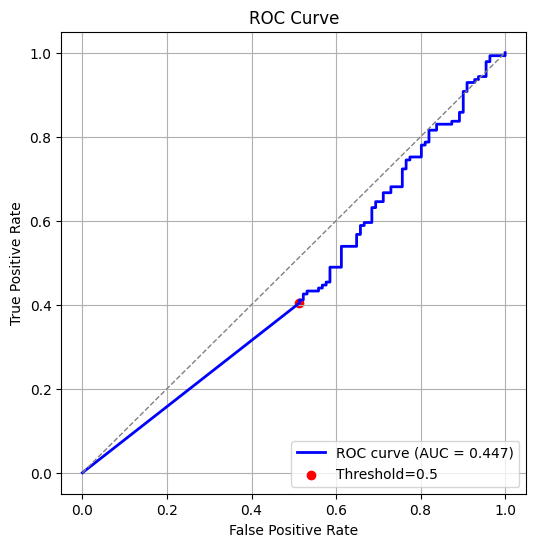

In [13]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]} # try 6 different values of C

grid = GridSearchCV(
    SVC(kernel='linear', probability=True),
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='accuracy'
)

grid.fit(X_train, L_train)
svm = grid.best_estimator_ # choose the best model from the grid search

model_summary(svm)

svm_prob = svm.predict_proba(X_test)
svm_pred = svm.predict(X_test)
_, accuracy, _, _, _ = evaluate_model(svm_prob, svm_pred, L_test)
add_model_result(f"SVM-LIN_{svm.C}", accuracy)

SVM Summary

Kernel: rbf
C: 0.001
Intercept: 0.9901
Support vectors per class: [491 491]
Total support vectors: 982

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   0(0.00%)     0(0.00%)
Up     111(44.05%)     141(55.95%)

Accuracy  : 0.5595 (55.95%)
Error Rate: 0.4405 (44.05%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 0


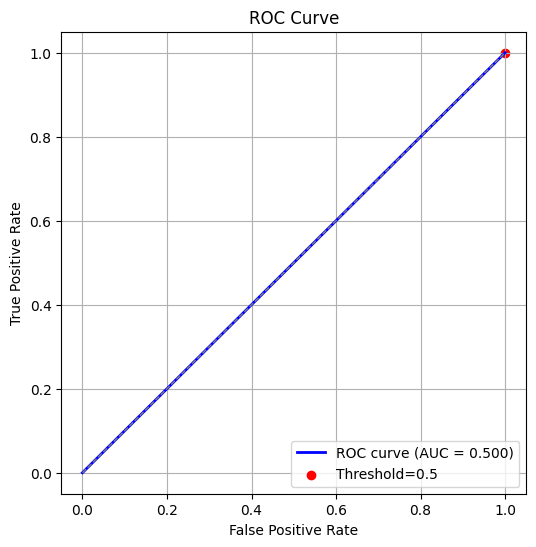

In [14]:

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]} # try 6 different values of C

grid = GridSearchCV(
    SVC(kernel='rbf', probability=True),
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='accuracy'
)

grid.fit(X_train, L_train)
svm = grid.best_estimator_ # choose the best model from the grid search

model_summary(svm)

svm_prob = svm.predict_proba(X_test)
svm_pred = svm.predict(X_test)
_, accuracy, _, _, _ = evaluate_model(svm_prob, svm_pred, L_test)
add_model_result(f"SVM-RBF_{svm.C}", accuracy)

<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

### 4.3.8 NN Neural Network

In machine learning, a neural network (also artificial neural network or neural net, abbreviated ANN or NN) is a computational model inspired by the structure and functions of biological neural networks

| Biological Neuron | Artificial Neuron | Notes |
|-------------------|-------------------| ------|
| Dendrites (dendriti) <br> receive inputs signal $\vec{x}_i$ | Input nodes receive the feature vector $\vec{x_i} \in \mathbb{R}^d$| Input nodes number = feature number = $d$ <br> Number of samples = $N \quad i \in [1,N]$ |
| Cell body (soma) <br> integrates signal | Weighted sum of inputs is computed | single neuron: $\hspace{4em} \underset{1 \times 1}{z_i} = \underset{1 \times d}{\vec{u}^T} \cdot \underset{d \times 1}{\vec{x}_i} + \underset{1 \times 1}{c}$ <br> layer with n neurones: $\quad \underset{n \times 1}{\vec{z_i}} = \underset{n \times d}{U} \cdot \underset{d \times 1}{\vec{x}_i} + \underset{n \times 1}{\vec{c}}$ |
| Threshold triggers firing | Activation function $f(z)$ decides output <br> (applied element-wise) | ReLU or other non-linear function <br> Number of neurons: hyperparameter |
| Axon (sinapsi) <br> output to next cells | Output passed to next layer <br> Regression: 1 neuron (linear output, no activation) <br> Binary Classif: 1 neuron; $f_{out} = $ sigmoid func <br> Multiclass Classif: k neurons; $f_{out} = $ softmax <br> Multilabel Classif: k neurons; $f_{out} = $ independent sigmoid | $ \underset{1 \times 1}{y_i} = f_{out} \left( \underset{1 \times d}{\vec{w}^T} \cdot \underset{d \times 1}{f(\vec{z}_i)} + \underset{1 \times 1}{b} \right)$ |

- perceptron (step func): $f(z_i) = \begin{cases} 0 \ if \ z_i \le 0 \\ 1 \ if \ z_i \gt 0 \end{cases}$ 
- common activate functions:
    - linear func: $f(z_i) = z_i$
    - tanh func: $ \displaystyle \tanh(z_i) = \frac{\sinh(z_i)}{\cosh{z_i}} = \frac{ e^{z_i} - e^{-z_i}}{e^{z_i}+e^{-z_i}}\\[4pt]$
    - sigmoid func: $ \displaystyle f(z_i) = \frac{1}{1+e^{-z_i}}\\[4pt]$ 
    - softmax func: $\displaystyle f(z_i) = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}},  \quad z ∈ \mathbb{R}^K\\[4pt]$ 
    - ReLU func: $f(z_i) = \max(z_i, 0)$
- If a layer has multiple neurons, the above functions are applied element-wise to the vector $\vec{z_i}$
- We can have an arbitrary number of hidden layers (i.e., depth) and an arbitrary number of neurons in each hidden layer (i.e., width).
- One hidden layer with one neuron performs linear classification.
- The deeper and wider the network, the more complex the decision boundary becomes.
- It was shown by (Cybenko, 1989) that a MLP (or NN) with a single hidden layer containing enough neurons and a non-linear activation function can approximate any continuous function. This is called the **Universal Approximation Theorem**.
- A NN model is defined by learning all its parameters, including the weight matrices $U$ and bias vectors $\vec{c}$ of each layer. In particular, $U$ and $\vec{c}$ define the hidden layer transformation, while $\vec{w}$ and $b$ define the final decision function. These parameters are jointly optimized:
    - defininig a Cost Function, often <br>
    $\quad \mathcal{J}(y, \hat{y}) = BCE(y,\hat y) \triangleq - [y \log{\hat y} + (1-y) \log (1-\hat y)]$  
    - using gradient descent, or better stochastic gradient descent (SGD), to find the optimum (BCE is not analytically invertible) <br>
    $ \quad \vec{w} \leftarrow \vec{w} - \alpha \nabla_{\vec{w}} \cdot \mathcal{J}(y, \hat{y}) $
    - gradient-based optimization requires differentiable functions (e.g., ReLU is piecewise differentiable)
    - gradients are computed using backpropagation <br>
    $ \hspace{3em} \displaystyle \frac{\partial \mathcal{J}}{\partial \vec{w}} = \frac{\partial \mathcal{J}}{\partial a_L} \ \prod_{l=L}^{1} \frac{\partial a_l}{\partial z_l} \ \frac{\partial z_l}{\partial \vec{w}} \quad$ where 
        - $L$ hidden layers number + 1 (output layer), 
        - $a_l$ signal at the end of $l^{th}$ layer
        - Gradient computation follows the chain rule decomposition: <br>
        $\quad$ gradient = local gradient × upstream gradient <br>
        which corresponds to the sequential product of partial derivatives along the computational graph.
        - Backpropagation is an algorithm for propagating gradients on a directed acyclic computational graph (DAG). It is based on the chain rule and implemented as a reverse topological traversal, from outputs back to inputs.
        - Backpropagation is analogous to dynamic programming: it avoids redundant computations by storing intermediate results (gradients of sub-expressions), similarly to the Fibonacci recursion optimization. However, it operates on a computational graph where gradients are propagated backward and aggregated across multiple paths.


Stopped due to max_epochs

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   38(15.08%)     35(13.89%)
Up     73(28.97%)     106(42.06%)

Accuracy  : 0.5714 (57.14%)
Error Rate: 0.4286 (42.86%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 0


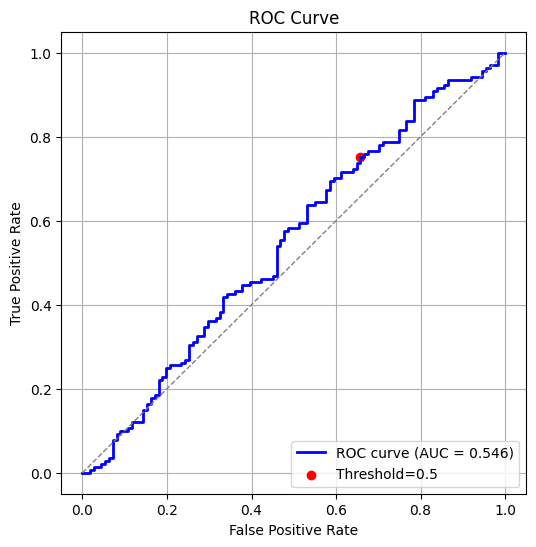

In [15]:
import torch
import torch.nn as nn
from torch.optim import SGD

torch.manual_seed(42)
np.random.seed(42)

# Neural Network model
class Classifier(nn.Module):
    neurons_hidden = 10 # number of neurons in the hidden layer
    def __init__(self):
        super().__init__()
        self.layer_hidden = nn.Linear(X_train.shape[1], self.neurons_hidden) # automatic input sizing, z = Ux + c
        self.relu = nn.ReLU() # a = max(z,0)
        self.layer_output = nn.Linear(self.neurons_hidden, 1)

    def forward(self, x):
        # layers sequentially applied to the input
        x = self.layer_hidden(x)
        x = self.relu(x)
        x = self.layer_output(x)
        return x
    
    def grad_norm(self):
        # compute the L2 norm of the gradients for all parameters
        total_norm = 0.0
        for p in self.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        return total_norm

NN = Classifier() # create an instance of the neural network model

criterion = nn.BCEWithLogitsLoss() # Loss function for binary classification (logistic regression)
optimizer = SGD(NN.parameters(), lr=0.01) # SGD optimizer with learning rate 0.01

# Data to tensor (data struct used in pytorch)
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values, dtype=torch.float32)
L_train_t = torch.tensor(L_train.values.reshape(-1, 1), dtype=torch.float32)
L_test_t  = torch.tensor(L_test.values, dtype=torch.float32)

# Training
max_epochs = 10000
grad_threshold = 1e-4
epoch = 0

while True:
    optimizer.zero_grad()
    outputs = NN(X_train_t)
    loss = criterion(outputs, L_train_t)
    loss.backward() # compute gradients
    total_norm = NN.grad_norm() # compute gradient norm
    optimizer.step() # update weights
    epoch += 1 # epoch is the number of iterations of the training loop

    # stopping conditions
    if total_norm < grad_threshold:
        print(f"Stopped at epoch {epoch} (grad norm = {total_norm:.6f})")
        break
    if epoch >= max_epochs:
        print("Stopped due to max_epochs")
        break

# Predictions
with torch.no_grad():
    nn_prob_pos = torch.sigmoid(NN(X_test_t)).detach().numpy().ravel()
    nn_prob = np.vstack([1 - nn_prob_pos, nn_prob_pos]).T
    nn_pred = (nn_prob_pos > 0.5).astype(int)

# Evaluation
_, accuracy, _, _, _ = evaluate_model(nn_prob, nn_pred, L_test.values)

add_model_result(f"NN_{NN.neurons_hidden}", accuracy)

<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

### 4.3.99 Accuracy Summary

In [16]:
df = pd.DataFrame(model_results)
df = df.sort_values(by="Accuracy", ascending=False)
    
print("\nModel Comparison:")
print(df.to_string(index=False, formatters={"Accuracy": "{:.2%}".format}))


Model Comparison:
        Model Accuracy
          QDA   59.92%
           NB   59.52%
        NN_10   57.14%
           LR   55.95%
          LDA   55.95%
SVM-RBF_0.001   55.95%
  SVM-LIN_0.1   55.95%
           DT   54.37%
       KNN_29   50.40%
